In [48]:
import numpy as np
from scipy import linalg

class Camera(object):

    def __init__(self, P):
        self.P = P
        self.K = None
        self.R = None
        self.t = None
        self.c = None
        self.factor()
        self.center()

    def project(self, X):
        x = np.dot(self.P, X)
        x = x / x[2]
        return x

    def factor(self):
        K, R = linalg.rq(self.P[:,:3])
        T = np.diag(np.sign(np.diag(K)))

        self.K = np.dot(K, T)
        self.R = np.dot(T, R)
        self.t = np.dot(linalg.inv(cam.K), P[:, 3])

    def center(self):
        if self.c is not None:
            return self.c
        else:
            self.factor()
            self.c = -np.dot(self.R.T, self.t)


def rotation_matrix(a):
    #  https://stackoverflow.com/a/25709323/684592
    R = np.eye(4)
    R[:3, :3] = linalg.expm([
        [0,-a[2],a[1]],
        [a[2],0,-a[0]],
        [-a[1],a[0],0]]
    )
    return R

K = np.array([[1000., 0., 500.], [0, 1000., 300.], [0, 0, 1.]])
tmp = rotation_matrix([0,0,1])[:3,:3]
Rt = np.hstack([tmp, np.array([[50], [40], [30]])])
P = np.dot(K, Rt)
cam = Camera(P)
cam.factor()

In [49]:
np.allclose(cam.K, K)

True

In [50]:
np.allclose(Rt[:,3], cam.t)

True

In [52]:
np.allclose(Rt[:3,:3], cam.R)

True

In [41]:
np.dot(linalg.inv(cam.K), P[:, 3])

array([50., 40., 30.])

In [10]:
import numpy as np
from scipy import linalg

def M(axis, theta):
    # https://stackoverflow.com/a/25709323/684592
    # https://en.wikipedia.org/wiki/Rodrigues%27_rotation_formula#Matrix_notation
    a = axis / linalg.norm(axis) * theta
    tmp = np.cross(np.eye(3), a)
    return linalg.expm(tmp)

v, axis, theta = [3, 5, 0], [4, 4, 1], 1.2
M0 = M(axis, theta)

print(v)
print(M0)
print(np.dot(M0, v))


[3, 5, 0]
[[ 0.67151763  0.1469127   0.72627869]
 [ 0.47140706  0.67151763 -0.57169875]
 [-0.57169875  0.72627869  0.38168025]]
[2.74911638 4.77180932 1.91629719]


In [5]:
points = np.loadtxt('../data/house.p3d')
points = np.vstack((points.T, np.ones(points.shape[0])))



In [21]:
P = np.hstack((np.eye(3), np.array([[0, 0, 1]]).T))
cam = Camera(P)
x = cam.project(points)

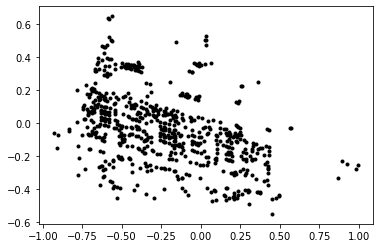

In [36]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(x[0], x[1], 'k.')
plt.show()

In [39]:
r = 0.05 * np.random.rand(3)
rot = rotation_matrix(r)


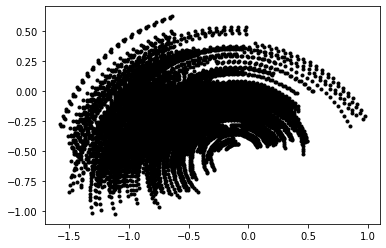

In [41]:
plt.figure()
for _ in range(20):
    cam.P = np.dot(cam.P, rot)
    x = cam.project(points)
    plt.plot(x[0], x[1], 'k.')
plt.show()

In [18]:
cam.K

array([[ 1.00000000e+03, -1.36887502e-13,  5.00000000e+02],
       [ 0.00000000e+00, -1.00000000e+03,  3.00000000e+02],
       [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]])

In [19]:
K

array([[1000.,    0.,  500.],
       [   0., 1000.,  300.],
       [   0.,    0.,    1.]])

In [7]:
tmp

array([[ 0.54030231, -0.84147098,  0.        ,  0.        ],
       [ 0.84147098,  0.54030231,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  1.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])